In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
import plotly.graph_objects as go

Iteration: 1
-8.63679743973128


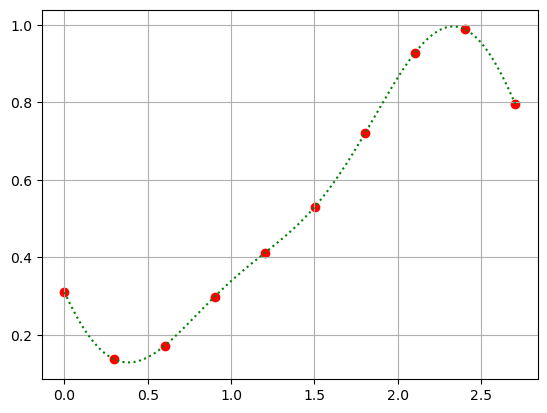

-6.790947022608476


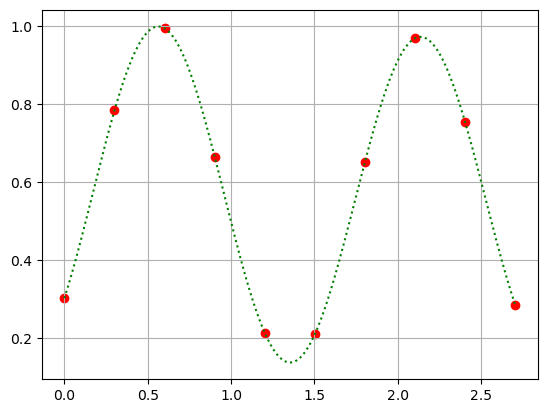

-17.680172805170663


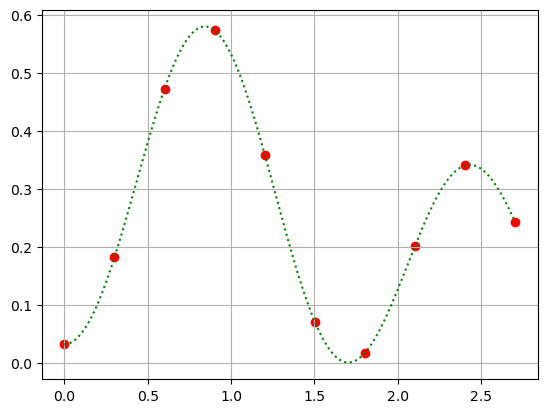


Iteration: 2
-17.680172805170663


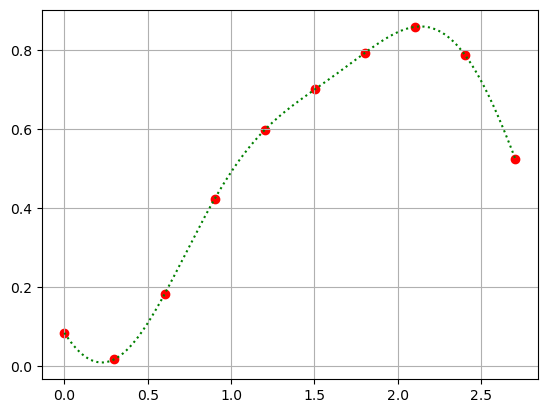

-30.539581663149047


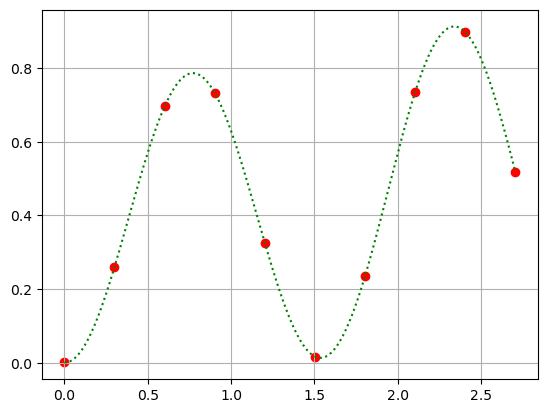

-30.539581663149047


C:\Users\fniel\AppData\Local\Temp\ipykernel_8696\4275054552.py:86: OptimizeWarning: Covariance of the parameters could not be estimated
  params, _ = curve_fit(fit_P,alpha,valz)


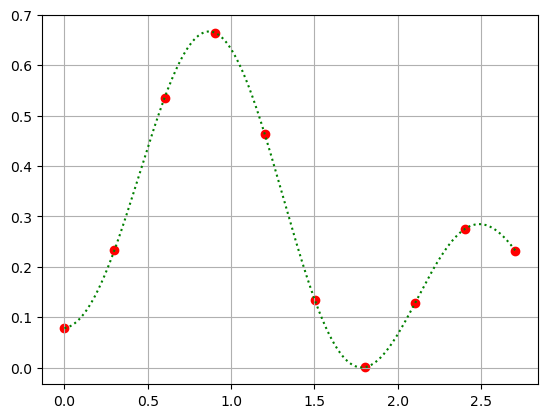


Power (dBm): -30.539581663149047
Best arm positions: (0.3005844822879123, 0.0, 1.8035068937274739)


In [ ]:
a = 0.133
d = 125 * 10**-6
D = 18 * 10**-3
l = 1550 * 10**-9

def deg2rad(deg):
    return deg * np.pi/180

def delta(N):
    return 2*np.pi**2*a*N*(d**2)/(l*D)

def Stokes(E):
    Ex, Ey = E[0], E[1]
    S0 = np.abs(Ex)**2 + np.abs(Ey)**2
    S1 = np.abs(Ex)**2 - np.abs(Ey)**2
    S2 = 2 * np.real(Ex * np.conjugate(Ey))
    S3 = 2 * np.imag(Ex * np.conjugate(Ey))
    return np.array([S0, S1, S2, S3])

def M(delta,alpha):
    c = np.cos(2*alpha)
    s = np.sin(2*alpha)
    cd = np.cos(delta)
    sd = np.sin(delta)
    return np.array([
        [1, 0, 0, 0],
        [0, c**2 + s**2*cd, c*s*(1-cd), -s*sd],
        [0, c*s*(1-cd), c**2*cd + s**2, c*sd],
        [0, s*sd, -c*sd, cd]
    ])

def S_out(alpha1,alpha2,alpha3,S_in):
    return (M(delta(1),alpha3)@M(delta(2),alpha2)@M(delta(1),alpha1)) @ S_in

def s(S):
    return S[1:] / S[0]

def Pv(S0,s):
    return S0/2*(1-s[0])

def fit_P(alpha,A0,A2c,A2s,A4c,A4s):
    return A0 + A2c*np.cos(2*alpha) + A2s*np.sin(2*alpha) + A4c*np.cos(4*alpha) + A4s*np.sin(4*alpha)

def optimize(iterations,S0,E_in,res):
    alpha = np.linspace(0,deg2rad(155),10)
    alpha_fit = np.linspace(0,deg2rad(155),2000)
    y = deg2rad(res[0])
    z = deg2rad(res[1])
    for i in range(iterations):
        print(f"Iteration: {i+1}")
        valx = np.array([])
        for v in alpha:
            valx = np.append(valx,Pv(S0,s(S_out(v,y,z,Stokes(E_in)))))
        p = min(valx)
        idx = list(valx).index(p)
        x = alpha[idx]
        print(10*np.log10(p))
        params, _ = curve_fit(fit_P,alpha,valx)
        plt.figure()
        plt.scatter(alpha,valx,color='red')
        plt.plot(alpha_fit,fit_P(alpha_fit,*params),':',color='green',)
        plt.grid()
        plt.show()

        valy = np.array([])
        for v in alpha:
            valy = np.append(valy,Pv(S0,s(S_out(x,v,z,Stokes(E_in)))))
        p = min(valy)
        idy = list(valy).index(p)
        y = alpha[idy]
        print(10*np.log10(p))
        params, _ = curve_fit(fit_P,alpha,valy)
        plt.figure()
        plt.scatter(alpha,valy,color='red')
        plt.plot(alpha_fit,fit_P(alpha_fit,*params),':',color='green')
        plt.grid()
        plt.show()

        valz = np.array([])
        for v in alpha:
            valz = np.append(valz,Pv(S0,s(S_out(x,y,v,Stokes(E_in)))))
        p = min(valz)
        idz = list(valz).index(p)
        z = alpha[idz]
        print(10*np.log10(p))
        params, _ = curve_fit(fit_P,alpha,valz)
        plt.figure()
        plt.scatter(alpha,valz,color='red')
        plt.plot(alpha_fit,fit_P(alpha_fit,*params),':',color='green')
        plt.grid()
        plt.show()
        print("")
    print(f"Power (dBm): {10*np.log10(p)}")
    print(f"Best arm positions: {x,y,z}")

def power_optimize(iterations,res):
    alpha = np.linspace(0,deg2rad(155),10)
    alpha_fit = np.linspace(0,deg2rad(155),2000)
    y = deg2rad(res[0])
    z = deg2rad(res[1])
    v = [0,y,z]
    for i in range(iterations):
        print(f"Iteration: {i+1}")
        for j in range(3):
            val = np.array([])
            for a in alpha:
                if j==0:
                    val = np.append(val,"Indsæt power funktion med ændring af den først vinkel")
                elif j==1:
                    val = np.append(val,"Indsæt power funktion med ændring af den anden vinkel")
                else:
                    val = np.append(val,"Indsæt power funktion med ændring af den tredje vinkel")
            p = min(val)
            idx = list(val).index(p)
            v[j] = alpha[idx]
            print(10*np.log10(p))
            params, _ = curve_fit(fit_P,alpha,val)
            plt.figure()
            plt.scatter(alpha,val,color='red')
            plt.plot(alpha_fit,fit_P(alpha_fit,*params),':',color='green',)
            plt.grid()
            plt.show()
    return np.asarray(v)

S0 = 1
E_H = np.cos(deg2rad(38))
E_V = np.exp(1.1j)*np.sin(deg2rad(38))
E_in = np.array([[E_H],[E_V]])
reset = [77,77]

optimize(2,S0,E_in,reset)

In [44]:
def mw2dbm(mw):
    return 10*np.log10(mw)

def ahat(u,port='V'):
    Mret = M(delta(1),u[2]) @ M(delta(2),u[1]) @ M(delta(1),u[0])
    a_pbs = np.asarray(port)
    #if port=='H':
    #    a_pbs = np.array([1,0,0])
    #else:
    #    a_pbs = np.array([-1,0,0])
    return Mret[1:,1:].T @ a_pbs

def estimate_s(P,U,S0,sigma,port='V'):
    A = np.vstack([ahat(u,port) for u in U])
    y = (2*np.asarray(P)/S0) - 1
    sigma_y = 2*np.asarray(sigma)/S0
    W = np.diag(1/sigma_y**2)
    s_raw = np.linalg.solve(A.T @ W @ A, A.T @ W @ y)
    Cov_raw = np.linalg.inv(A.T @ W @ A)
    s_norm = np.linalg.norm(s_raw)
    s_est = s_raw/s_norm
    J = np.eye(3)/s_norm - np.outer(s_raw,s_raw)/(s_norm**3)
    Cov_norm = J @ Cov_raw @ J.T
    return s_est, Cov_norm

E_true = np.array([
    np.cos(deg2rad(38)),
    np.exp(1.1j)*np.sin(deg2rad(38))
])

S0 = 0.5
S_true = Stokes(E_true)
s_true = s(S_true)

U = np.array([
    np.array([deg2rad(45),0,0]),
    np.array([deg2rad(90),deg2rad(155),deg2rad(90)]),
    np.array([0,deg2rad(45),deg2rad(90)]),
    np.array([deg2rad(135),deg2rad(155),deg2rad(90)]),
    np.array([deg2rad(155),deg2rad(23),deg2rad(155)]),
    np.array([deg2rad(68),deg2rad(90),deg2rad(23)])
])

P_meas = []
sigma = []
for u in U:
    Sout = (M(delta(1),u[2]) @ M(delta(2),u[1]) @ M(delta(1),u[0])) @ S_true
    Pk = Pv(S0,s(Sout))
    usigma = 0.05*Pk
    sigma.append(usigma)
    P_meas.append(np.random.normal(loc=Pk,scale=usigma))

s_est = estimate_s(P_meas,U,S0,sigma,'V')[0]
s_est_Cov = estimate_s(P_meas,U,S0,sigma,'V')[1]
s_est_std = np.sqrt(np.diag(s_est_Cov))

print(f"s_true: {s_true}")
print(f"s_est: {s_est}")
print(f"std: {s_est_std}")

E_est = np.array([
    np.sqrt((1+s_est[0])/2),
    (s_est[1]-complex(0,s_est[2]))/np.sqrt(2*(1+s_est[0]))
])

print(f"E_true: {E_true}")
print(f"E_est: {E_est}")

UFuncTypeError: ufunc 'matmul' did not contain a loop with signature matching types (dtype('float64'), dtype('<U1')) -> None

In [42]:
def tan_basis(s):
    if abs(s[0]) < 0.9:
        a = np.array([1,0,0])
    else:
        a = np.array([0,1,0])
    e1 = a - np.dot(a,s) * s
    e1_norm = e1/np.linalg.norm(e1)
    e2 = np.cross(s,e1_norm)
    e2_norm = e2/np.linalg.norm(e2)
    B = np.column_stack((e1_norm,e2_norm))
    return B

def sphere_map(s,v):
    r = np.linalg.norm(v)
    if r<1e-14:
        return s.copy()
    return np.cos(r)*s+np.sin(r)*(v/r)

def unc_patch(s_est,Cov,nsigma=1):
    P = np.eye(3) - np.outer(s_est,s_est)
    Cov_tan = P @ Cov @ P
    B = tan_basis(s_est)
    Cov_2D = B.T @ Cov_tan @ B
    Cov_2D = 0.5 * (Cov_2D + Cov_2D.T)
    evals, evecs = np.linalg.eigh(Cov_2D)
    evals = np.clip(evals,0,None)
    axes = nsigma * np.sqrt(evals)
    A = evecs @ np.diag(axes)
    r_vals = np.linspace(0,1,25)
    phi_vals = np.linspace(0,2*np.pi,80)
    X = np.zeros((25,80))
    Y = X
    Z = Y
    for i, rho in enumerate(r_vals):
        for j, phi in enumerate(phi_vals):
            u = np.array([rho*np.cos(phi),rho*np.sin(phi)])
            xi = A @ u
            v = B @ xi
            p = sphere_map(s_est,v)
            X[i,j],Y[i,j],Z[i,j] = p
    boundary = []
    for phi in phi_vals:
        u = np.array([np.cos(phi),np.sin(phi)])
        xi = A @ u
        v = B @ xi
        p = sphere_map(s_est,v)
        boundary.append(p)
    boundary = np.array(boundary)
    return X,Y,Z,boundary

def poincare_w_unc(s_true,s_est,Cov,nsigma=1):
    Xp,Yp,Zp,boundary = unc_patch(s_est,Cov,nsigma=nsigma)

    u = np.linspace(0,2*np.pi,180)
    v = np.linspace(0,np.pi,90)

    Xs = np.outer(np.cos(u),np.sin(v))
    Ys = np.outer(np.sin(u),np.sin(v))
    Zs = np.outer(np.ones_like(u),np.cos(v))

    fig = go.Figure()
    fig.add_trace(go.Surface(
        x=Xs,y=Ys,z=Zs,
        opacity=0.18,
        showscale=False,
        name="Poincaré sphere"
    ))

    fig.add_trace(go.Scatter3d(x=[-1,1],y=[0,0],z=[0,0],mode='lines',name='S1 axis'))
    fig.add_trace(go.Scatter3d(x=[0,0],y=[-1,1],z=[0,0],mode='lines',name='S2 axis'))
    fig.add_trace(go.Scatter3d(x=[0,0],y=[0,0],z=[-1,1],mode='lines',name='S3 axis'))

    fig.add_trace(go.Scatter3d(
        x=[s_true[0]],y=[s_true[1]],z=[s_true[2]],
        mode='markers+text',
        marker=dict(size=6),
        text=['s_true'],
        textposition='top center',
        name='s_true'
    ))

    fig.add_trace(go.Scatter3d(
        x=[s_est[0]],y=[s_est[1]],z=[s_est[2]],
        mode='markers+text',
        marker=dict(size=6),
        text=['s_est'],
        textposition='top center',
        name='s_est'
    ))

    fig.add_trace(go.Surface(
        x=Xp,y=Yp,z=Zp,
        opacity=0.55,
        showscale=False,
        name=f"{nsigma}σ region"
    ))

    fig.add_trace(go.Scatter3d(
        x=boundary[:,0],y=boundary[:,1],z=boundary[:,2],
        mode='lines',
        line=dict(width=6),
        name=f"{nsigma}σ boundary"
    ))

    fig.update_layout(
        title=f"Interactive Poincaré sphere with wrapped {nsigma}σ uncertainty region",
        scene=dict(
            xaxis=dict(title='S1',range=[-1,1]),
            yaxis=dict(title='S2',range=[-1,1]),
            zaxis=dict(title='S3',range=[-1,1]),
            aspectmode='cube'
        )
    )

    fig.show()
    fig.write_html("poincare_w_unc.html")

poincare_w_unc(s_true,s_est,s_est_Cov,2)

In [47]:
def normalize(v):
    norm = np.linalg.norm(v)
    if norm < 1e-14:
        return v
    return v/norm

def pbs_axis(s_known, P_meas, S0, eta=1):
    s_known = np.asarray(s_known)
    P_meas = np.asarray(P_meas).reshape(-1)
    y = 2 * P_meas / (eta * S0) - 1
    A = s_known
    AtWA = A.T @ A
    AtWy = A.T @ y
    a_raw = np.linalg.solve(AtWA, AtWy)
    Cov = np.linalg.inv(AtWA)
    std = np.sqrt(np.diag(Cov))
    a_est = normalize(a_raw)
    residuals = y - A @ a_raw
    return a_est, Cov, std, residuals

s_known = np.array([
    normalize([1,0,0]),
    normalize([-1,0,0]),
    normalize([0,1,0]),
    normalize([0,-1,0]),
    normalize([0,0,1]),
    normalize([0,0,-1]),
])

a_est = pbs_axis(s_known, P_meas, S0, eta=1)[0]

E_true = np.array([
    np.cos(deg2rad(38)),
    np.exp(1.1j)*np.sin(deg2rad(38))
])

S0 = 0.5
S_true = Stokes(E_true)
s_true = s(S_true)

U = np.array([
    np.array([deg2rad(45),0,0]),
    np.array([deg2rad(90),deg2rad(155),deg2rad(90)]),
    np.array([0,deg2rad(45),deg2rad(90)]),
    np.array([deg2rad(135),deg2rad(155),deg2rad(90)]),
    np.array([deg2rad(155),deg2rad(23),deg2rad(155)]),
    np.array([deg2rad(68),deg2rad(90),deg2rad(23)])
])

P_meas = []
sigma = []
for u in U:
    Sout = (M(delta(1),u[2]) @ M(delta(2),u[1]) @ M(delta(1),u[0])) @ S_true
    Pk = Pv(S0,s(Sout))
    usigma = 0.05*Pk
    sigma.append(usigma)
    P_meas.append(np.random.normal(loc=Pk,scale=usigma))

s_est = estimate_s(P_meas,U,S0,sigma,port=a_est)[0]
s_est_Cov = estimate_s(P_meas,U,S0,sigma,port=a_est)[1]
s_est_std = np.sqrt(np.diag(s_est_Cov))

print(f"s_true: {s_true}")
print(f"s_est: {s_est}")
print(f"std: {s_est_std}")

E_est = np.array([
    np.sqrt((1+s_est[0])/2),
    (s_est[1]-complex(0,s_est[2]))/np.sqrt(2*(1+s_est[0]))
])

print(f"E_true: {E_true}")
print(f"E_est: {E_est}")

poincare_w_unc(s_true,s_est,s_est_Cov,2)

s_true: [ 0.2419219   0.44012238 -0.86473469]
s_est: [ 0.00602533  0.4235543  -0.90585068]
std: [0.03330619 0.03081192 0.01428647]
E_true: [0.78801075+0.j         0.27926166+0.54868204j]
E_est: [0.70923386+0.j         0.29859989+0.63861212j]
